## Materials

In [ ]:
# Is your stuff mounted?
from google.colab import drive
drive.mount('/content/drive')
#!ls /content/drive/

Mounted at /content/drive


In [335]:
# import dependencies
import cv2
import dlib
import math
import matplotlib
import matplotlib.pyplot as plt
import ninja
import numpy as np
import PIL
from PIL import Image

In [34]:
#get and decompress landmarks detector module from dlib repo
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 "shape_predictor_68_face_landmarks.dat.bz2"
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

--2026-04-21 21:19:51--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-21 21:19:51--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2.1’

shape_predictor_68_ 100%[===================>]  61.07M  50.5MB/s    in 1.2s    

2026-04-21 21:19:53 (50.5 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2.1’ saved [64040097/64040097]

bunzip2: Output file shape_predictor_68_face_landmarks.dat already exists.


In [339]:
#pulling from my download of the Chicago Face Database photos
!mkdir raw
!cp /content/drive/MyDrive/CFD/AF-219/CFD-AF-219-106-N.jpg raw/
!mv raw/CFD-AF-219-106-N.jpg raw/f.jpg
!ls raw/

mkdir: cannot create directory ‘raw’: File exists
f1.jpg	f2.jpg	f.jpg


In [343]:
def align_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector(gray, 1)

    if len(faces) == 0:
        return None  # No faces detected

    aligned_faces = []
    for face in faces:
        landmarks = predictor(gray, face)
        # Parse landmarks.
        face_landmarks = [(item.x, item.y) for item in predictor(gray, face).parts()]
        lm = np.array(face_landmarks)

        lm_chin          = lm[0  : 17]  # left-right
        lm_eyebrow_left  = lm[17 : 22]  # left-right
        lm_eyebrow_right = lm[22 : 27]  # left-right
        lm_nose          = lm[27 : 31]  # top-down
        lm_nostrils      = lm[31 : 36]  # top-down
        lm_eye_left      = lm[36 : 42]  # left-clockwise
        lm_eye_right     = lm[42 : 48]  # left-clockwise
        lm_mouth_outer   = lm[48 : 60]  # left-clockwise
        lm_mouth_inner   = lm[60 : 68]  # left-clockwise

        # Calculate auxiliary vectors.
        eye_left     = np.mean(lm_eye_left, axis=0)
        eye_right    = np.mean(lm_eye_right, axis=0)
        eye_avg      = (eye_left + eye_right) * 0.5
        eye_to_eye   = eye_right - eye_left
        mouth_left   = lm_mouth_outer[0]
        mouth_right  = lm_mouth_outer[6]
        mouth_avg    = (mouth_left + mouth_right) * 0.5
        eye_to_mouth = mouth_avg - eye_avg

        # Calculate border
        x = eye_to_eye - np.flipud(eye_to_mouth)
        x /= np.hypot(*x)
        x *= max(np.hypot(*eye_to_eye) * 2.0, np.hypot(*eye_to_mouth) * 1.8)
        y = np.flipud(x) * [-1, 1]

        c = eye_avg + eye_to_mouth * 0.1

        quad = np.stack([c - x - y, c - x + y, c + x + y, c + x - y])
        qsize = np.hypot(*x) * 2
        border = max(int(np.rint(qsize * 0.25)), 3)

        # GET ANGLE
        # Extract the coordinates of the landmarks for both eyes
        # Left Eye: Landmarks 36 to 41
        left_eye_points = [(landmarks.part(i).x, landmarks.part(i).y) for i in range(36, 42)]

        # Right Eye: Landmarks 42 to 47
        right_eye_points = [(landmarks.part(i).x, landmarks.part(i).y) for i in range(42, 48)]

        # For the left eye: Compute the bounding box
        lmax_x, lmax_y = max(left_eye_points, key=lambda x: (x[0], x[1]))
        lmin_x, lmin_y = min(left_eye_points, key=lambda x: (x[0], x[1]))

        # For the right eye: Compute the bounding box
        rmax_x, rmax_y = max(right_eye_points, key=lambda x: (x[0], x[1]))
        rmin_x, rmin_y = min(right_eye_points, key=lambda x: (x[0], x[1]))

        # Calculate the center of each eye
        lcenter_x, lcenter_y = (lmax_x + lmin_x) // 2, (lmax_y + lmin_y) // 2
        rcenter_x, rcenter_y = (rmax_x + rmin_x) // 2, (rmax_y + rmin_y) // 2

        # Compute the horizontal and vertical distances between the eye centers
        X = np.abs(lcenter_x - rcenter_x)
        Y = np.abs(lcenter_y - rcenter_y)

        # Calculate the angle between the eyes
        alpha = np.degrees(np.arcsin(X / np.sqrt(X**2 + Y**2)))
        angle = 90 - alpha

        # ROTATION
        # Get the image dimensions
        h, w = image.shape[:2]

        # Decide the rotation direction based on eye centers' vertical position
        if lcenter_y > rcenter_x:
            # Rotate clockwise
            rotation_matrix = cv2.getRotationMatrix2D((lcenter_x, lcenter_y), angle, 1.0)
        else:
            # Rotate counterclockwise
            rotation_matrix = cv2.getRotationMatrix2D((lcenter_x, lcenter_y), -angle, 1.0)

        # Apply the rotation
        # borderMode 1 is replication of nearby pixels, 2 is reflection
        rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h), borderMode = 2)

        # CROP TO FACE
        # Detect the face in the rotated image
        rotFace = detector(rotated_image, 1)

        # get rotated landmarks
        rot_landmarks = [(item.x, item.y) for item in predictor(rotated_image, rotFace[0]).parts()]
        rlm = np.array(rot_landmarks)

        # Find the eyes again
        rlm_eye_left      = rlm[36 : 42]  # left-clockwise
        rlm_eye_right     = rlm[42 : 48]  # left-clockwise

        # Get center
        reye_left     = np.mean(rlm_eye_left, axis=0)
        reye_right    = np.mean(rlm_eye_right, axis=0)
        reye_avg      = (reye_left + reye_right) * 0.5

        # Calculate horizontal modifier
        h_dist = math.floor((rotFace[0].right()-rotFace[0].left())/2)+border

        #tweaked bounding box
        #defining vertical modifiers such that i'm not cutting off the top
        #without going out of bounds, at least for my stimulus source
        newT = math.floor((rotFace[0].top()*0.025))
        newB = math.floor((rotFace[0].bottom()*1.975))

        newL = math.floor((reye_avg[0]-h_dist))
        newR = math.floor((reye_avg[0]+h_dist))

        # Crop the image to the detected face area
        aligned_face = rotated_image[newT:newB, newL:newR]

        #append to set
        aligned_faces.append(aligned_face)

    return aligned_faces

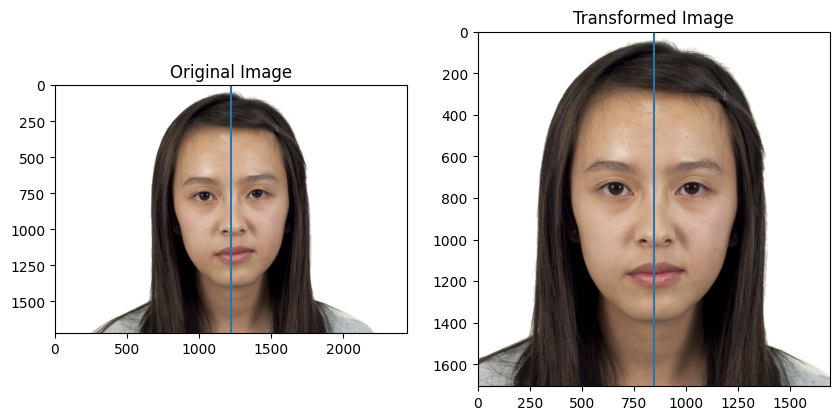

In [347]:
# Load the image
image = cv2.imread("raw/f.jpg")

# Align the faces
aligned_faces = align_face(image)

# Display the faces
plt.figure(figsize=(10, 5))

#converts from BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
aligned_face = cv2.cvtColor(aligned_faces[0], cv2.COLOR_BGR2RGB)

# OG
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axvline(x=math.floor(image.shape[1]/2))
plt.axis('on')

# Aligned
plt.subplot(1, 2, 2)
plt.imshow(aligned_face)
plt.title('Transformed Image')
plt.axvline(x=math.floor(aligned_face.shape[1]/2))
plt.axis('on')

# Show all images in one window
plt.show()

In [345]:
#relatively little loss of the original
print(image.shape)
print(aligned_face.shape)

(1718, 2444, 3)
(1706, 1694, 3)


In [356]:
path = "/content/drive/MyDrive/AlignedPics/"
!mkdir path
dest = f"{path}aligned_face.png"

mkdir: cannot create directory ‘path’: File exists
